# 분류모델 평가

# 01. 이진 분류 평가

| 이름                 | 설명                                             | 수식                                                            |
| ------------------ | ---------------------------------------------- | ------------------------------------------------------------- |
| Accuracy (정확도)     | 전체 샘플 중 올바르게 예측된 비율 (불균형 데이터에서는 한계 있음)         | $$\frac{TP + TN}{TP + TN + FP + FN}$$                         |
| Precision (정밀도)    | Positive로 예측한 것 중 실제 Positive 비율 (FP 줄이는 데 중요) | $$\frac{TP}{TP + FP}$$                                        |
| Recall (재현율 / 민감도) | 실제 Positive 중 맞춘 비율 (FN 줄이는 데 중요)              | $$\frac{TP}{TP + FN}$$                                        |
| F1-Score           | Precision과 Recall의 조화 평균 (불균형 데이터에서 유용)        | $$2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}$$ |
| Specificity (특이도)  | 실제 Negative 중 맞춘 비율                            | $$\frac{TN}{TN + FP}$$                                        |
| ROC Curve          | 임계값 변화에 따른 TPR vs FPR 관계를 시각화                  | $$TPR=\frac{TP}{TP+FN},\ FPR=\frac{FP}{FP+TN}$$               |
| AUC                | ROC Curve 아래 면적 (1에 가까울수록 좋음)                  | ROC Curve의 면적                                                 |

### 혼동행렬 Confusion Matrix

|               | 예측 값 부정 (Negative) | 예측 값 긍정 (Positive) |
|---------------|------------------------|------------------------|
| 실제 값 부정 (Negative) | True Negative (TN)         | False Positive (FP)        |
| 실제 값 긍정 (Positive) | False Negative (FN)        | True Positive (TP)         |

![](https://d.pr/i/2c98lS+)

In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [64]:
# 전처리 함수 정의
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

def handlena(df):
    age_imputer = SimpleImputer(strategy='mean')
    df[['Age']] = age_imputer.fit_transform(df[['Age']])
    cabin_imputer = SimpleImputer(strategy='constant', fill_value='N')
    df[['Cabin']] = cabin_imputer.fit_transform(df[['Cabin']])
    embarked_imputer = SimpleImputer(strategy='most_frequent')
    df[['Embarked']] = embarked_imputer.fit_transform(df[['Embarked']])
    return df

def drop_features(df):
    return df.drop(['PassengerId', 'Name', 'Ticket'], axis=1)

def format_features(df):
    # 범주형을 라벨 인코더로 수정
    df['Cabin'] = df['Cabin'].str[:1]   # 첫번째 문자만 가져오기
    for feat in ['Sex', 'Cabin', 'Embarked']:
        labelEncoder = LabelEncoder()
        df[feat] = labelEncoder.fit_transform(df[feat])
    return df

def preprocess_titanic(df):
    df = handlena(df)
    df = drop_features(df)
    df = format_features(df)
    return df

In [65]:
# 타이타닉 데이터 로드
titanic_df = pd.read_csv('data/titanic_train.csv')

# 입력, 라벨 분리
X_titatic_df = titanic_df.drop('Survived', axis=1)
y_titatic_df = titanic_df['Survived']

# 전처리 과정 추가
X_titatic_df = preprocess_titanic(X_titatic_df)

X_titatic_df

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,3,1,22.000000,1,0,7.2500,7,2
1,1,0,38.000000,1,0,71.2833,2,0
2,3,0,26.000000,0,0,7.9250,7,2
3,1,0,35.000000,1,0,53.1000,2,2
4,3,1,35.000000,0,0,8.0500,7,2
...,...,...,...,...,...,...,...,...
886,2,1,27.000000,0,0,13.0000,7,2
887,1,0,19.000000,0,0,30.0000,1,2
888,3,0,29.699118,1,2,23.4500,7,2
889,1,1,26.000000,0,0,30.0000,2,0


In [66]:
# 모델 학습/평가
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_titatic_df, y_titatic_df, random_state=0, stratify=y_titatic_df
)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(668, 8) (668,)
(223, 8) (223,)


In [67]:
from sklearn.linear_model import LogisticRegression # 분류 모델

lr_clf = LogisticRegression(max_iter=1000)
lr_clf.fit(X_train, y_train)

# 정확도 평가
print(lr_clf.score(X_train, y_train))
print(lr_clf.score(X_test, y_test))

0.8023952095808383
0.7847533632286996


### 정확도 Accuracy
모든 샘플수 중의 정답비율

$
Accuracy = \frac{TP + TN}{TP + TN + FP + FN}
$

데이터가 불균형한 경우(즉, 긍정과 부정 샘플의 수가 크게 다른 경우) 정확도는 비현실적인 성능을 나타낼 수 있다.

불균형 데이터 예시:
만약 실제로 1000개의 데이터 중에서 990개가 부정(Negative)이고 10개만이 긍정(Positive)인 경우라면, 모든 샘플을 부정으로만 예측해도 정확도는 99%입니다.

$ \text { Accuracy }=\frac{990}{1000}=99 \% $

In [68]:
from sklearn.base import BaseEstimator
from sklearn.metrics import accuracy_score

class PerfectTitanicClassifier(BaseEstimator):
    """성별특성만을 구분해서 생존을 예측하는 모델"""
    
    def fit(self, X, y):
        """아무것도 학습하지 않도록 오버라이딩"""
        pass

    def predict(self, X):
        """
        입력 데이터의 성별 컬럼(Sex)을 조회
        - 여성(0)인 경우 : 1 생존 예측
        - 남성(1)인 경우 : 0 사망 예측
        """
        pred = np.zeros((X.shape[0], 1))
        # 모든 데이터를 순회하며 성별 검사
        for i in range(X.shape[0]):
            if X['Sex'].iloc[i] == 0:   # 여성인 경우
                pred[i] = 1     # 생존
        return pred
    
    def score(self, X, y):
        return accuracy_score(y, self.predict(X))


In [69]:
# 모델 학습 및 평가
my_clf = PerfectTitanicClassifier()
my_clf.fit(X_train, y_train)

print(my_clf.score(X_train, y_train))
print(my_clf.score(X_test, y_test))

0.7919161676646707
0.7713004484304933


In [70]:
# 혼동행렬 확인
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, my_clf.predict(X_test)))
# TN 115
# TP 57
# FN 29
# FP 22

# 정확도
print((115 + 57) / (115 + 22 + 29 + 57))

[[115  22]
 [ 29  57]]
0.7713004484304933


In [71]:
from sklearn.base import BaseEstimator
from sklearn.metrics import accuracy_score

class PerfectTitanicClassifier2(BaseEstimator):
    """무조건 사망으로 예측하는 모델"""
    
    def fit(self, X, y):
        """아무것도 학습하지 않도록 오버라이딩"""
        pass

    def predict(self, X):
        """무조건 0으로 응답하여 사망으로 예측"""
        return np.zeros((X.shape[0], 1))
    
    def score(self, X, y):
        return accuracy_score(y, self.predict(X))


In [72]:
# 모델 학습 및 평가
my_clf = PerfectTitanicClassifier2()
my_clf.fit(X_train, y_train)

print(my_clf.score(X_train, y_train))
print(my_clf.score(X_test, y_test))

0.6167664670658682
0.6143497757847534


In [73]:
# 혼동행렬 확인
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, my_clf.predict(X_test)))

# TP, FP가 모두 0으로 출력 되어 정확도는 값이 나오지만 정밀도, 재현율은 문제가 생김

[[137   0]
 [ 86   0]]


### Precision 정밀도

$정밀도 = \frac{TP}{TP + FP}$

Positive(양성)이라고 예측한 것중에 정답인 확률

**정밀도가 중요한 지표**
음성인 데이터를 양성으로 예측하면 큰일나는 경우
- 스팸메일 분류 (스팸메일이 아닌데, 스팸으로 분류하면 업무상 큰 혼란을 야기한다. 반면, 양성을 음성으로 분류하는 것(스팸메일을 분류하지 못한것)은 상대적으로 피해가 적다.)

In [74]:
from sklearn.metrics import precision_score

# 모두 사망으로 예측해서 정확도는 61% 인 모델의 정밀도 연산
precision_score(y_test, my_clf.predict(X_test))

c:\Users\Playdata\AppData\Local\miniforge3\envs\ai_basic_env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


0.0

In [75]:
# 일반 예측 모델에서의 정밀도
lr_clf = LogisticRegression(max_iter=1000)
lr_clf.fit(X_train, y_train)

# 정밀도 확인
print(precision_score(y_test, lr_clf.predict(X_test)))

# 혼동행렬 확인
print(confusion_matrix(y_test, lr_clf.predict(X_test)))
print(56 / (56 + 18))


0.7567567567567568
[[119  18]
 [ 30  56]]
0.7567567567567568


### Recall 재현율
$재현율 = \frac{TP}{FN + TP}$

실제 Positive(양성)인 대상중에 Positive라고 예측한 확률

**재현율이 중요한 지표**
양성인 데이터를 음성으로 잘못 판단하면 큰일나는 경우.
- 보험/금융사기
- 암진단

In [76]:
# 재현율 평가
from sklearn.metrics import recall_score

# 모두 사망으로 예측해서 정확도 61% 획득한 모델
print(recall_score(y_test, my_clf.predict(X_test)))

0.0


In [77]:
# 일반 모델 재현율
print(recall_score(y_test, lr_clf.predict(X_test)))

# 혼동 행렬
print(confusion_matrix(y_test, lr_clf.predict(X_test)))
print(56 / (30 + 56))

0.6511627906976745
[[119  18]
 [ 30  56]]
0.6511627906976745


### Precision/Recall Trade-off
분류 결정 임계치 Confidence Threshold를 조정하면 정밀도와 재현율을 상호 보완할 수 있다.

**Precision/Recall Trade-off 요약**

* **분류 결정 임계치(Threshold)** 를 조정하면 **정밀도(Precision)** 와 **재현율(Recall)** 사이에 균형을 조절할 수 있다.
* **임계치 낮춤** → Positive 예측 증가 → **재현율↑**, **정밀도↓**

  * FN 감소 → Recall 분모 작아짐 → Recall 증가
  * FP 증가 → Precision 분모 커짐 → Precision 감소
* **임계치 높임** → Positive 예측 감소 → **정밀도↑**, **재현율↓**

  * FN 증가 → Recall 분모 커짐 → Recall 감소
  * FP 감소 → Precision 분모 작아짐 → Precision 증가

**상황별 전략**

* **정밀도 100%**: 확실한 경우에만 Positive 예측 → **임계치 높임**
* **재현율 100%**: 모두 Positive로 예측 → **임계치 낮춤**
* **재현율 중시**: 암 진단, 금융 사기 → **임계치 낮춤**
* **정밀도 중시**: 스팸 필터링, 광고 타깃팅 → **임계치 높임**



In [78]:
# 로지스틱 회귀 분류모델의 예측치
print(lr_clf.predict(X_test[20:25]))

# 확률이 0.5(분류 결정 임계치) 이상이면 양성, 0.5 미만이면 음성으로 판단
print(lr_clf.predict_proba(X_test[20:25]))

[1 1 0 0 0]
[[0.05444801 0.94555199]
 [0.1135679  0.8864321 ]
 [0.90096319 0.09903681]
 [0.86504493 0.13495507]
 [0.84257418 0.15742582]]


In [79]:
# Binarizer 클래스를 활용한 임계치 수정
from sklearn.preprocessing import Binarizer

proba = [[0.9], [0.2], [0.4], [0.1], [0.7]]

# 임계치를 0.5에서 0.3으로 변경하면 문턱이 낮아지면서 재현율이 올라감
# 임계치를 0.7로 변경하면 문턱이 높아지면서 정밀도가 올라감
binarizer = Binarizer(threshold=0.5)
pred = binarizer.fit_transform(proba)
print(pred)

[[1.]
 [0.]
 [0.]
 [0.]
 [1.]]


In [80]:
from sklearn.metrics import f1_score
# 이진분류 종합 평가 함수
def eval_bi_clf(y_true, y_pred):
    """
    y_true: 실제값
    y_pred: 모델 예측값
    """
    print(f"혼동행렬 : {confusion_matrix(y_true, y_pred)}")
    print(f"정확도(Accuracy) : {accuracy_score(y_true, y_pred)}")
    print(f"정밀도(Precision) : {precision_score(y_true, y_pred)}")
    print(f"재현율(Recall) : {recall_score(y_true, y_pred)}")
    print(f"F1점수(F1-score) : {f1_score(y_true, y_pred)}")

In [81]:
# 타이타닉 데이터셋에 임계기준치 수정 테스트

# 양성일 확률 값만 사용
pred_proba = lr_clf.predict_proba(X_test)[:, 1:]
print(pred_proba[20:25])
pred = lr_clf.predict(X_test)
print(pred[20:25])

# threshold 조정
threshold = 0.5
binarizer = Binarizer(threshold=threshold)
y_pred = binarizer.fit_transform(pred_proba)
print(y_pred[20:25])

print('threshold = 0.5')
eval_bi_clf(y_test, y_pred)


[[0.94555199]
 [0.8864321 ]
 [0.09903681]
 [0.13495507]
 [0.15742582]]
[1 1 0 0 0]
[[1.]
 [1.]
 [0.]
 [0.]
 [0.]]
threshold = 0.5
혼동행렬 : [[119  18]
 [ 30  56]]
정확도(Accuracy) : 0.7847533632286996
정밀도(Precision) : 0.7567567567567568
재현율(Recall) : 0.6511627906976745
F1점수(F1-score) : 0.7


In [82]:
# threshold 조정
threshold = 0.9
binarizer = Binarizer(threshold=threshold)
y_pred = binarizer.fit_transform(pred_proba)
print(y_pred[20:25])

print('threshold = 0.9')
eval_bi_clf(y_test, y_pred)


[[1.]
 [0.]
 [0.]
 [0.]
 [0.]]
threshold = 0.9
혼동행렬 : [[136   1]
 [ 69  17]]
정확도(Accuracy) : 0.6860986547085202
정밀도(Precision) : 0.9444444444444444
재현율(Recall) : 0.19767441860465115
F1점수(F1-score) : 0.3269230769230769


In [83]:
# threshold 조정
threshold = 0.1
binarizer = Binarizer(threshold=threshold)
y_pred = binarizer.fit_transform(pred_proba)
print(y_pred[20:25])

print('threshold = 0.1')
eval_bi_clf(y_test, y_pred)


[[1.]
 [1.]
 [0.]
 [1.]
 [1.]]
threshold = 0.1
혼동행렬 : [[44 93]
 [ 4 82]]
정확도(Accuracy) : 0.5650224215246636
정밀도(Precision) : 0.4685714285714286
재현율(Recall) : 0.9534883720930233
F1점수(F1-score) : 0.6283524904214559


In [84]:
# 임계치에 따른 정밀도/재현율 시각화
from sklearn.metrics import precision_recall_curve

# 다양한 threshold 기준으로 Precision / Recall 을 계산하는 함수
precisions, recalls, thresholds = precision_recall_curve(y_test, pred_proba)

# 배열 크기 확인
print(precisions.shape)     # thresholds 수 + 1 : 마지막에 1
print(recalls.shape)        # thresholds 수 + 1 : 마지막에 0
print(thresholds.shape)

# 일부 출력
# 임계치가 낮은 부분을 살펴보면 정밀도 낮고 재현율 높음
# 임계치가 높은 부분을 살펴보면 정밀도 높고 재현율 낮음
# start = 0
# stop = 10
start = -10
stop = None
print(precisions[start:stop])
print(recalls[start:stop])
print(thresholds[start:stop])

(212,)
(212,)
(211,)
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
[0.10465116 0.09302326 0.08139535 0.06976744 0.05813953 0.04651163
 0.03488372 0.02325581 0.01162791 0.        ]
[0.94555199 0.94621789 0.9503941  0.95193158 0.95915819 0.96282826
 0.96393797 0.96721055 0.96845579 0.97175971]


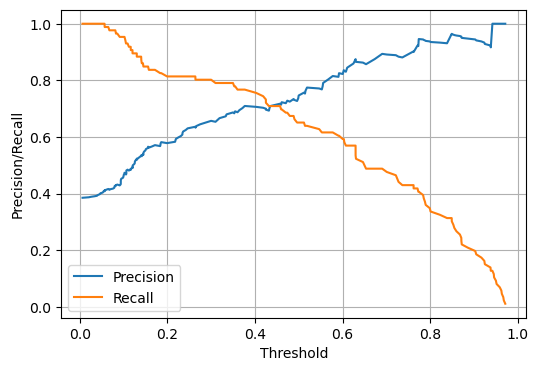

In [85]:
plt.figure(figsize=(6, 4))
plt.plot(thresholds, precisions[:-1], label="Precision")
plt.plot(thresholds, recalls[:-1], label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Precision/Recall")
plt.legend()
plt.grid()
plt.show()

### F1 Score

정확도는 불균형한 데이터에서 신뢰하기 어렵기 때문에, 정밀도(Precision)와 재현율(Recall)이 보완 지표로 사용된다. 하지만 이 두 지표에도 각각의 맹점이 존재한다.

**정밀도를 100%로 만드는 방법**
정밀도는 $ \text{Precision} = \frac{TP}{TP + FP} $ 로 정의된다. 확실한 경우에만 Positive로 예측하고 나머지는 모두 Negative로 예측하면, 정밀도를 100%로 만들 수 있다. 예를 들어, 전체 환자가 1000명인데 그 중에서 확실히 양성이라고 판단되는 환자가 단 1명이라고 가정한다. 이 1명만 Positive로 예측하고 나머지를 모두 Negative로 예측하면 FP는 0이고 TP는 1이 되며, 정밀도는 $ \frac{1}{1+0} = 1.0 $ 이 되어 100%가 된다.

**재현율을 100%로 만드는 방법**
재현율은 $ \text{Recall} = \frac{TP}{TP + FN} $ 으로 정의된다. 모든 환자를 Positive로 예측하면 재현율은 100%가 된다. 예를 들어, 전체 환자 1000명을 모두 Positive로 예측하면 FN은 0이 되며, 실제 양성자가 30명이라고 해도 재현율은 $ \frac{30}{30+0} = 1.0 $ 이 된다.

**F1 Score의 개념**
F1 스코어는 정밀도와 재현율의 조화를 고려한 지표이다. 이 스코어는 두 값이 어느 한쪽으로 치우치지 않을 때 높은 값을 가진다. F1 스코어는 다음과 같은 공식으로 계산한다:

$$
F1 = \frac{2}{\frac{1}{recall} + \frac{1}{precision}} = 2 \cdot \frac{precision \cdot recall}{precision + recall}
$$

예를 들어, A 모델은 정밀도가 0.9이고 재현율이 0.1이라면, F1 스코어는 약 0.18이 된다. 반면, B 모델은 정밀도와 재현율이 각각 0.5로 균형이 맞는 경우이며, 이때 F1 스코어는 0.5로 계산된다. 이처럼 정밀도와 재현율 중 한쪽이 지나치게 낮으면 F1 점수도 낮아진다. 따라서 A 모델보다 B 모델이 더 우수한 성능을 가진다고 볼 수 있다.

**F1 Score는 F-Score의 특수한 경우이며, 베타(β) 값이 1일 때를 의미한다.**
베타 값은 재현율의 중요도를 조절하는 요소로, 보통 2 또는 0.5가 사용된다. 베타가 2이면 재현율에 더 가중치를 두며, 0.5이면 정밀도에 더 가중치를 둔다.

Fβ 점수의 일반적인 공식은 다음과 같다:

$$
F_{\beta}=\left(1+\beta^{2}\right) \cdot \frac{precision \cdot recall}{\beta^{2} \cdot precision + recall}
$$

또는 TP, FN, FP를 이용한 식은 다음과 같다:

$$
F_{\beta}=\frac{(1+\beta^{2}) \cdot TP}{(1+\beta^{2}) \cdot TP + \beta^{2} \cdot FN + FP}
$$

이와 같은 방식으로 F-Score는 평가 목적에 따라 정밀도와 재현율의 중요도를 다르게 조절할 수 있다.

In [86]:
# threshold에 따른 f1 score 확인
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

for threshold in thresholds:
    binarizer = Binarizer(threshold=threshold)
    y_pred = binarizer.fit_transform(lr_clf.predict_proba(X_test)[:, 1:])
    print(f"\n===threshold {threshold} ===")
    eval_bi_clf(y_test, y_pred)


===threshold 0.3 ===
혼동행렬 : [[101  36]
 [ 18  68]]
정확도(Accuracy) : 0.757847533632287
정밀도(Precision) : 0.6538461538461539
재현율(Recall) : 0.7906976744186046
F1점수(F1-score) : 0.7157894736842105

===threshold 0.4 ===
혼동행렬 : [[110  27]
 [ 21  65]]
정확도(Accuracy) : 0.7847533632286996
정밀도(Precision) : 0.7065217391304348
재현율(Recall) : 0.7558139534883721
F1점수(F1-score) : 0.7303370786516854

===threshold 0.5 ===
혼동행렬 : [[119  18]
 [ 30  56]]
정확도(Accuracy) : 0.7847533632286996
정밀도(Precision) : 0.7567567567567568
재현율(Recall) : 0.6511627906976745
F1점수(F1-score) : 0.7

===threshold 0.6 ===
혼동행렬 : [[126  11]
 [ 35  51]]
정확도(Accuracy) : 0.7937219730941704
정밀도(Precision) : 0.8225806451612904
재현율(Recall) : 0.5930232558139535
F1점수(F1-score) : 0.6891891891891891

===threshold 0.7 ===
혼동행렬 : [[132   5]
 [ 45  41]]
정확도(Accuracy) : 0.7757847533632287
정밀도(Precision) : 0.8913043478260869
재현율(Recall) : 0.47674418604651164
F1점수(F1-score) : 0.6212121212121212


### ROC Curve & AUC

#### ROC Curve (수신자 조작 특성 곡선)

ROC 곡선은 다양한 임계값에서의 분류 모델 성능을 시각화한 그래프이다.  
이 곡선은 x축에 **False Positive Rate (FPR)**, y축에 **True Positive Rate (TPR, 재현율)** 을 나타낸다.

* **FPR**은 실제로는 음성인 데이터를 양성으로 잘못 예측한 비율이다.  
  예를 들어, 암이 아닌 사람을 암이라고 예측하거나, 일반 메일을 스팸으로 잘못 분류하는 경우이다.  
  FPR은 다음 수식으로 계산한다:  
  $$ FPR = \frac{FP}{FP + TN} $$

* **TPR**은 실제로 양성인 데이터 중에서 올바르게 양성으로 예측한 비율이다.  
  예를 들어, 암 환자를 정확히 암이라고 진단하거나, 스팸 메일을 올바르게 스팸으로 예측한 경우이다.  
  TPR은 재현율(recall)이라고도 하며, 다음 수식으로 계산한다:  
  $$ TPR = \frac{TP}{TP + FN} $$

ROC 곡선은 임계값(threshold)에 따라 FPR과 TPR이 어떻게 변화하는지를 보여준다.  
임계값을 조정하면 TPR과 FPR의 값도 함께 바뀌며, 이를 통해 모델의 성능을 전체적으로 파악할 수 있다.

* 임계값이 **0**일 경우, 모든 데이터를 Positive로 예측하게 된다.  
  이때 TN은 0이 되고,  
  $FPR = \frac{FP}{FP + 0} = 1$  
  재현율도 1이 된다.

* 임계값이 **1**일 경우, 모든 데이터를 Negative로 예측하게 된다.  
  이때 FP는 0이 되고,  
  $FPR = \frac{0}{0 + TN} = 0$  
  재현율도 0이 된다.

#### AUC (Area Under the Curve)

AUC는 ROC 곡선 아래의 면적을 의미하며, 모델의 분류 성능을 하나의 수치로 요약한 지표이다.  
AUC 값은 **0.0에서 1.0 사이**의 값을 가지며, 높을수록 모델의 성능이 우수함을 의미한다.

* AUC = **1.0**: 모든 예측이 완벽한 모델이다.  
* AUC = **0.5**: 무작위로 예측하는 모델과 동일하며, 아무런 분류 능력이 없는 경우이다.  
* AUC = **0.0**: 예측이 모두 반대로 된 최악의 모델이다.  

AUC 값이 클수록 TPR은 높고 FPR은 낮다는 의미이므로, 분류 성능이 우수하다고 판단할 수 있다.

In [88]:
from sklearn.metrics import roc_curve, roc_auc_score

y_true = np.array([0, 0, 1, 1])
y_pred_score = np.array([0.1, 0.4, 0.35, 0.8])

fpr, tpr, thresholds = roc_curve(y_true, y_pred_score)
"""
임계치 기준
inf: 양성이 없는 경우
0.8: 1개 양성 예측
0.4: 2개 양성 예측
0.35: 3개 양성 예측
0.1: 4개 양성 예측
"""

print('fpr: ', fpr)
print('tpr: ', tpr)
print('thresholds: ', thresholds)


fpr:  [0.  0.  0.5 0.5 1. ]
tpr:  [0.  0.5 0.5 1.  1. ]
thresholds:  [ inf 0.8  0.4  0.35 0.1 ]


In [89]:
# 타이타닉 데이터 적용
y_pred_proba = lr_clf.predict_proba(X_test)[:, 1]   # 양성 확률만
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

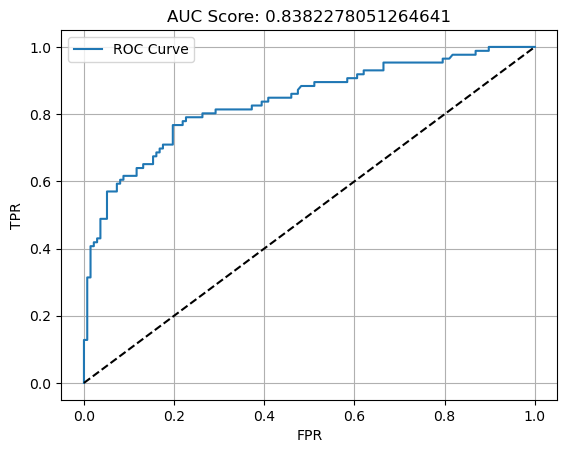

In [91]:
# 시각화
plt.plot(fpr, tpr, label="ROC Curve")
plt.plot([0, 1], [0, 1], 'k--')         # (0, 0), (1, 1)의 직선

plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()
plt.grid()
plt.title(f"AUC Score: {roc_auc_score(y_test, y_pred_proba)}")
plt.show()

# 02.다중 분류 평가
이진 분류와 동일하게 정확도, 정밀도, 재현율, F1-score등을 사용할 수 있다.
다중분류 문제에서는 여러 클래스를 동시에 평가하기 때문에, 각 지표를 계산하는 방식에 차이가 있다.

각 함수의 average 매개변수를 작성해야 한다.
- Micro Average: 모든 클래스에서의 TP, FP, FN을 합쳐서 계산한다.
- Macro Average: 각 클래스별로 계산한 지표의 평균을 구한다.
- Weighted Average: 각 클래스의 데이터 수에 따라 가중치를 적용하여 평균을 구한다.



그외
- Confusion Matrix: 각 클래스별로 모델의 예측 결과를 시각화한다.
    - 클래스별로 True Positive, False Positive, False Negative의 비율을 확인할 수 있다.
    - **True Negative는 별도로 계산할 필요가 없다.**
- Classification Report: 각 클래스에 대해 정밀도(precision), 재현율(recall), F1 점수(f1-score)를 출력하며, 전체 평균(accuracy, macro avg, weighted avg)을 함께 보여준다.
    - support값은 클래스의 실제 데이터 개수를 의미한다.


### 샘플 데이터 예시

다음은 **3개의 클래스 (A, B, C)** 가 있는 예시로, 모델이 예측한 결과와 실제 값이 어떻게 일치하는지를 보여주는 데이터이다.

**실제 값 (True Labels):**
- A, B, B, B, C, C, C

**모델 예측 (Predicted Labels):**
- B, A, B, B, A, C, C

**혼동 행렬 (Confusion Matrix):**


| 실제\예측 | A  | B  | C  |
|---|---|---|---|
| A | 0 | 1 | 0 |
| B | 1 | 2 | 0 |
| C | 1 | 0 | 2 |

- **True Positives (TP)**: 모델이 해당 클래스에 대해 맞춘 예측
- **False Positives (FP)**: 다른 클래스를 해당 클래스라고 잘못 예측한 경우
- **False Negatives (FN)**: 해당 클래스를 다른 클래스로 잘못 예측한 경우
- **True Negatives (TN)**: 해당 클래스가 아닌데 모델이 다른 클래스라고 맞춘 경우


![](https://d.pr/i/NA9XLb+)

**각 클래스별 Precision, Recall 계산:**

1. **클래스 A**:
   - Precision: $\frac{0}{0 + 2} = \frac{0}{2} = 0.00$
   - Recall: $\frac{0}{0 + 2} = \frac{0}{2} = 0.00$

2. **클래스 B**:
   - Precision: $\frac{2}{2 + 1} = \frac{2}{3} = 0.6667$
   - Recall: $\frac{2}{2 + 1} = \frac{2}{3} = 0.6667$

3. **클래스 C**:
   - Precision: $\frac{2}{2 + 0} = \frac{2}{2} = 1.00$
   - Recall: $\frac{2}{2 + 0} = \frac{2}{2} = 1.00$



**전체 Accuracy 계산**

전체 **Accuracy**는 모델이 정확하게 예측한 비율이다.

$
\text{Accuracy} = \frac{\text{True Positives}}{\text{전체 샘플 수}} = \frac{0 + 2 + 2}{7} = \frac{4}{7} \approx 0.5714
$

---

**`sklearn.metrics.classification_report`**



```text
              precision    recall  f1-score   support

           A       0.00      0.00      0.00         1
           B       0.67      0.67      0.67         3
           C       1.00      0.67      0.80         3

    accuracy                           0.57         7
   macro avg       0.56      0.44      0.49         7
weighted avg       0.71      0.57      0.63         7
```

- **precision**: TP / (TP + FP)
- **recall**: TP / (TP + FN)
- **f1-score**: 조화평균: `2 * (precision * recall) / (precision + recall)`
- **support**: 각 클래스의 실제 샘플 개수 (confusion matrix의 행의 합)
- **weighted avg**: 각 클래스의 support(샘플 수)로 가중 평균을 낸 것
- **macro avg**: 단순 평균 (support를 고려하지 않고, 클래스 수로 나누어 평균을 구함).

**도출과정**
```
① Macro Average: 단순 평균. 각 지표별로 클래스별 값들의 평균을 계산.

Precision (macro):
(0.00 + 0.67 + 1.00) / 3 = 0.5567

Recall (macro):
(0.00 + 0.67 + 1.00) / 3 = 0.5567

F1-score (macro):
(0.00 + 0.67 + 1.00) / 3 = 0.5567

※ 소수점 세 자리 반올림하면 0.56으로 보고됨.

② Weighted Average: 각 클래스별 support(샘플 수)를 가중치로 적용한 평균.

- Precision (weighted):
(0.00 × 2 + 0.67 × 3 + 1.00 × 2) / 7
= (0 + 2.00 + 2.00) / 7 = 0.5714

- Recall (weighted):
(0.00 × 2 + 0.67 × 3 + 1.00 × 2) / 7
= (0 + 2.00 + 2.00) / 7 = 0.5714

- F1-score (weighted):
(0.00 × 2 + 0.67 × 3 + 1.00 × 2) / 7
= (0 + 2.00 + 2.00) / 7 = 0.5714

※ 소수점 반올림하면 0.57로 보고됨.
```



In [93]:
# 실제 클래스 (정답)
y_true = ['A', 'B', 'B', 'B', 'C', 'C', 'C']

# 모델이 예측한 클래스
y_pred = ['B', 'A', 'B', 'B', 'A', 'C', 'C']

labels = ['A', 'B', 'C']
conf_mat = confusion_matrix(y_true, y_pred, labels=labels)
print(conf_mat)

conf_mat_df = pd.DataFrame(
    conf_mat, 
    index=['True A', 'True B', 'True C'], 
    columns=['Pred A', 'Pred B', 'Pred C']
    )

conf_mat_df

[[0 1 0]
 [1 2 0]
 [1 0 2]]


,Pred A,Pred B,Pred C
True A,0,1,0
True B,1,2,0
True C,1,0,2


In [94]:
# 레포트 확인
from sklearn.metrics import classification_report
print(classification_report(y_true, y_pred, labels=labels))

              precision    recall  f1-score   support

           A       0.00      0.00      0.00         1
           B       0.67      0.67      0.67         3
           C       1.00      0.67      0.80         3

    accuracy                           0.57         7
   macro avg       0.56      0.44      0.49         7
weighted avg       0.71      0.57      0.63         7

